# LP Implementation



## 1. Define the node layout

### 1.1 Define grid parameters

The node layout is based on a rectangular grid with uniform spacing.  
The user specifies the number of rows and columns

In [32]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

# User-defined grid parameters
n_rows_user = int(input("Enter the number of rows: "))
n_cols = int(input("Enter the number of columns: "))


dx = 1.0
dy = 1.0

Enter the number of rows:  3
Enter the number of columns:  3


### 1.2 User-defined grid size

The user specifies the number of rows and columns of the rectangular node grid.

Since the support conditions and point loads are now defined independently, no additional adjustment of the grid dimensions is required.

In [33]:
# Use the user-defined grid size directly
n_rows = n_rows_user

# Basic validity check
if n_rows < 2 or n_cols < 2:
    raise ValueError("Both n_rows and n_cols must be at least 2.")

print("Final grid size used:")
print("n_rows =", n_rows)
print("n_cols =", n_cols)

Final grid size used:
n_rows = 3
n_cols = 3


### 1.3 Create node coordinates

The node coordinates are generated row by row on a rectangular grid with spacing \(dx\) and \(dy\).

In [34]:
# Create node coordinates
nodes = []
for r in range(n_rows):
    for c in range(n_cols):
        x = c * dx
        y = r * dy
        nodes.append([x, y])

nodes = np.array(nodes)
n_nodes = len(nodes)

print("Number of nodes:", n_nodes)
print("First 5 node coordinates:")
print(nodes[:12])

Number of nodes: 9
First 5 node coordinates:
[[0. 0.]
 [1. 0.]
 [2. 0.]
 [0. 1.]
 [1. 1.]
 [2. 1.]
 [0. 2.]
 [1. 2.]
 [2. 2.]]


### 1.4 Plot the node grid


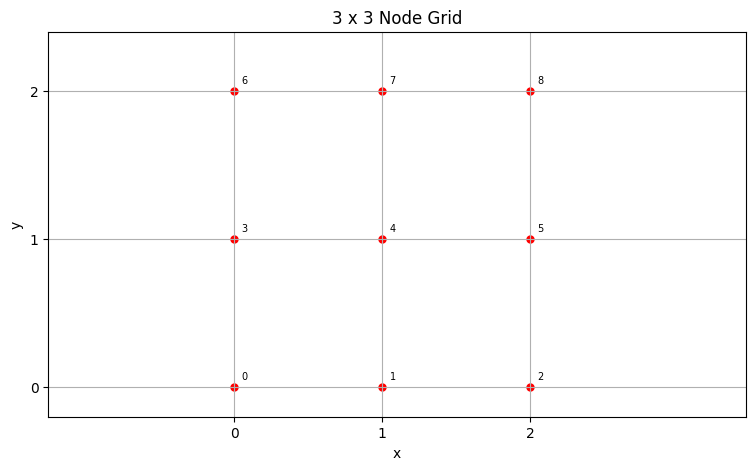

In [35]:
# Plot the node grid and label each node with its index
plt.figure(figsize=(9, 5))
plt.scatter(nodes[:, 0], nodes[:, 1], s=25, color="red")

for i, (x, y) in enumerate(nodes):
    plt.text(x + 0.05, y + 0.05, str(i), fontsize=7)

plt.axis("equal")
plt.xlim(-0.2, (n_cols - 1) * dx + 0.4)
plt.ylim(-0.2, (n_rows - 1) * dy + 0.4)
plt.xticks(np.arange(0, n_cols * dx, dx))
plt.yticks(np.arange(0, n_rows * dy, dy))
plt.grid(True)
plt.title(f"{n_rows} x {n_cols} Node Grid")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 2. Generate the ground structure

The ground structure is defined as the set of all candidate members connecting node pairs.


In [36]:
# Helper function to access node numbers by row and column
def node_id(r, c, n_cols):
    return r * n_cols + c

# Full ground structure: Take all node numbers from 0 up to n_nodes-1, and create all unique pairs
members = list(itertools.combinations(range(n_nodes), 2)) 
n_members = len(members)

print("Number of candidate members:", n_members)
print("First 10 members:")
print(members[:10])

Number of candidate members: 36
First 10 members:
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 2), (1, 3)]


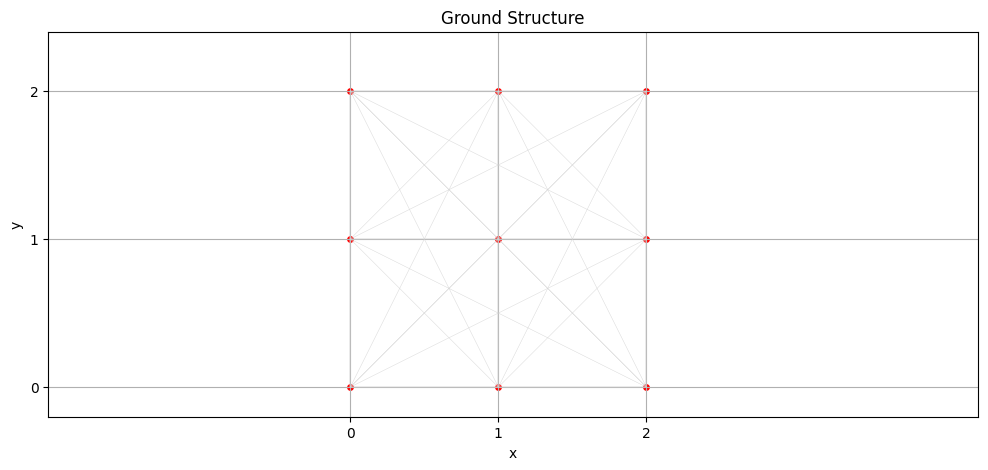

In [37]:
# Plot the ground structure
plt.figure(figsize=(12, 5))

# Plot members
for i, j in members:
    xi, yi = nodes[i]
    xj, yj = nodes[j]
    plt.plot([xi, xj], [yi, yj], color="lightgray", linewidth=0.3)

# Plot nodes
plt.scatter(nodes[:, 0], nodes[:, 1], s=15, color="red")

plt.axis("equal")
plt.xlim(-0.2, (n_cols - 1) * dx + 0.4)
plt.ylim(-0.2, (n_rows - 1) * dy + 0.4)
plt.xticks(np.arange(0, n_cols * dx, dx))
plt.yticks(np.arange(0, n_rows * dy, dy))
plt.grid(True)

plt.title("Ground Structure")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 3. Assemble the global equilibrium matrix

For each member, the unit direction vector is computed and inserted into the global equilibrium matrix.
Each free node contributes one equilibrium equation in x-direction and one in y-direction. This code assembles the full nodal equilibrium matrix that maps member axial forces to force balance at every node.

In [38]:
# Store geometric properties of each member
lengths = np.zeros(n_members) # creates an array(0), with one entry for each member
directions = np.zeros((n_members, 2)) # creates a 2D array(0,0)

# Loop over all candidate members
for k, (i, j) in enumerate(members): #loops through the full member list
    vec = nodes[j] - nodes[i] # vector from node i -> j
    L = np.linalg.norm(vec) # member length
    lengths[k] = L #stores the member length in the lengths array
    directions[k] = vec / L # unit vector

print("First 5 member lengths:")
print(lengths[:6])# e.g entries from 0-4

print("\nFirst 5 direction vectors:")
print(directions[:20])

First 5 member lengths:
[1.         2.         1.         1.41421356 2.23606798 2.        ]

First 5 direction vectors:
[[ 1.          0.        ]
 [ 1.          0.        ]
 [ 0.          1.        ]
 [ 0.70710678  0.70710678]
 [ 0.89442719  0.4472136 ]
 [ 0.          1.        ]
 [ 0.4472136   0.89442719]
 [ 0.70710678  0.70710678]
 [ 1.          0.        ]
 [-0.70710678  0.70710678]
 [ 0.          1.        ]
 [ 0.70710678  0.70710678]
 [-0.4472136   0.89442719]
 [ 0.          1.        ]
 [ 0.4472136   0.89442719]
 [-0.89442719  0.4472136 ]
 [-0.70710678  0.70710678]
 [ 0.          1.        ]
 [-0.70710678  0.70710678]
 [-0.4472136   0.89442719]]


In [39]:
#Creates a matrix full of zeros
A_full = np.zeros((2 * n_nodes, n_members)) # size=>rows:2 * n_nodes & columuns: n_members

# Loop over all candidate members, k = member index
for k, (i, j) in enumerate(members): 
    ux, uy = directions[k]

    # Rows for node i -> equilibrium at node i
    row_ix = 2 * i
    row_iy = 2 * i + 1

    # Rows for node j -> equilibrium at node j
    row_jx = 2 * j
    row_jy = 2 * j + 1

    # Contribution at node i
    A_full[row_ix, k] = ux
    A_full[row_iy, k] = uy

    # Contribution at node j
    A_full[row_jx, k] = -ux
    A_full[row_jy, k] = -uy

print("Shape of A_full:", A_full.shape)
print("Top-left corner of A_full:")
print(A_full[:8, :6])

Shape of A_full: (18, 36)
Top-left corner of A_full:
[[ 1.          1.          0.          0.70710678  0.89442719  0.        ]
 [ 0.          0.          1.          0.70710678  0.4472136   1.        ]
 [-1.          0.          0.          0.          0.          0.        ]
 [-0.          0.          0.          0.          0.          0.        ]
 [ 0.         -1.          0.          0.          0.          0.        ]
 [ 0.         -0.          0.          0.          0.          0.        ]
 [ 0.          0.         -0.          0.          0.          0.        ]
 [ 0.          0.         -1.          0.          0.          0.        ]]


## 4. Boundary conditions and loading

### 4.1 Input helper functions

The following helper functions make the user input more robust.

If an invalid value is entered, the program does not stop immediately.  
Instead, the corresponding value is requested again.

In [40]:
def ask_int(prompt, min_value=None, max_value=None):
    while True:
        try:
            value = int(input(prompt))

            if min_value is not None and value < min_value:
                print(f"Invalid input. Please enter an integer >= {min_value}.")
                continue

            if max_value is not None and value > max_value:
                print(f"Invalid input. Please enter an integer <= {max_value}.")
                continue

            return value

        except ValueError:
            print("Invalid input. Please enter an integer.")


def ask_float(prompt):
    while True:
        try:
            return float(input(prompt))
        except ValueError:
            print("Invalid input. Please enter a number, e.g. -1 or 0.5.")


def ask_dof_choice(prompt):
    while True:
        value = input(prompt).strip().lower()

        if value in ["x", "y", "xy", "yx"]:
            return value

        print("Invalid input. Please enter 'x', 'y', or 'xy'.")

### 4.2 User-defined support conditions

The support conditions are defined interactively by the user.

For each supported node, the user specifies:
- the node index,
- and whether the horizontal DOF, the vertical DOF, or both should be fixed.

Allowed choices are:
- `x`
- `y`
- `xy`

In [41]:
# Ask the user how many support nodes should be defined
n_supports = ask_int("Enter the number of supported nodes: ", min_value=1)

# Store support definitions here
supports = []

for k in range(n_supports):
    print(f"\nSupport {k+1}:")

    # Ask for node index
    node = ask_int(
    f"  Enter node index (0 to {n_nodes - 1}): ",
    min_value=0,
    max_value=n_nodes - 1
    )


    # Ask which directions are fixed
    dof_choice = ask_dof_choice("  Fix which DOFs? Enter 'x', 'y', or 'xy': ")


    # Save support definition
    supports.append({
        "node": node,
        "fix_x": "x" in dof_choice,
        "fix_y": "y" in dof_choice
    })

print("\nSupports:")
for s in supports:
    print(s)

# Build constrained DOF list
constrained_dofs = []

for s in supports:
    node = s["node"]

    if s["fix_x"]:
        constrained_dofs.append(2 * node)       # x DOF

    if s["fix_y"]:
        constrained_dofs.append(2 * node + 1)   # y DOF

# Remove duplicates and sort
constrained_dofs = np.array(sorted(set(constrained_dofs)))

# Build free DOF list
all_dofs = np.arange(2 * n_nodes)
free_dofs = np.setdiff1d(all_dofs, constrained_dofs)

print("\nConstrained DOFs:", constrained_dofs)
print("Number of constrained DOFs:", len(constrained_dofs))
print("Number of free DOFs:", len(free_dofs))

Enter the number of supported nodes:  2



Support 1:


  Enter node index (0 to 8):  0
  Fix which DOFs? Enter 'x', 'y', or 'xy':  xy



Support 2:


  Enter node index (0 to 8):  2
  Fix which DOFs? Enter 'x', 'y', or 'xy':  xy



Supports:
{'node': 0, 'fix_x': True, 'fix_y': True}
{'node': 2, 'fix_x': True, 'fix_y': True}

Constrained DOFs: [0 1 4 5]
Number of constrained DOFs: 4
Number of free DOFs: 14


### 4.3 User-defined point loads

The external point loads are defined interactively by the user.

For each load, the user specifies:
- the node at which the load acts,
- the horizontal component $F_x$,
- the vertical component $F_y$.

This allows arbitrary point-load configurations to be prescribed.

In [42]:
# Ask the user how many point loads should be applied
n_loads = ask_int("Enter the number of point loads: ", min_value=1)

# Store all loads in a list
loads = []

for k in range(n_loads):
    print(f"\nLoad {k+1}:")

    # Ask for the node where the load acts
    node = ask_int(
    f"  Enter node index (0 to {n_nodes - 1}): ",
    min_value=0,
    max_value=n_nodes - 1
    )

    # Ask for horizontal and vertical load components
    Fx = ask_float("  Enter horizontal load component Fx (positive = right, negative = left): ")
    Fy = ask_float("  Enter vertical load component Fy (positive = up, negative = down): ")

    # Save the load definition
    loads.append({
        "node": node,
        "Fx": Fx,
        "Fy": Fy
    })

print("\nLoads:")
for load in loads:
    print(load)

Enter the number of point loads:  1



Load 1:


  Enter node index (0 to 8):  2
  Enter horizontal load component Fx (positive = right, negative = left):  0
  Enter vertical load component Fy (positive = up, negative = down):  -1



Loads:
{'node': 2, 'Fx': 0.0, 'Fy': -1.0}


#### 4.3.1 Assemble the full load vector

The full nodal load vector is assembled from the user-defined point loads.

Each node contributes two entries:
- one for the horizontal degree of freedom,
- one for the vertical degree of freedom.

The reduced load vector is then obtained by selecting only the free degrees of freedom.

In [43]:
# Initialize the full load vector
b_full = np.zeros(2 * n_nodes)

# Insert all user-defined point loads into the full load vector
for load in loads:
    node = load["node"]
    Fx = load["Fx"]
    Fy = load["Fy"]

    b_full[2 * node] += Fx       # x DOF
    b_full[2 * node + 1] += Fy   # y DOF

# Reduce the load vector to free DOFs only
b = b_full[free_dofs]

print("Shape of b_full:", b_full.shape)
print("Nonzero entries in b_full:")
nz = np.nonzero(b_full)[0]
print(nz, b_full[nz])

print("\nShape of reduced b:", b.shape)
print("Reduced load vector b:")
print(b)

Shape of b_full: (18,)
Nonzero entries in b_full:
[5] [-1.]

Shape of reduced b: (14,)
Reduced load vector b:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 4.4 Plot the user-defined supports and  loads

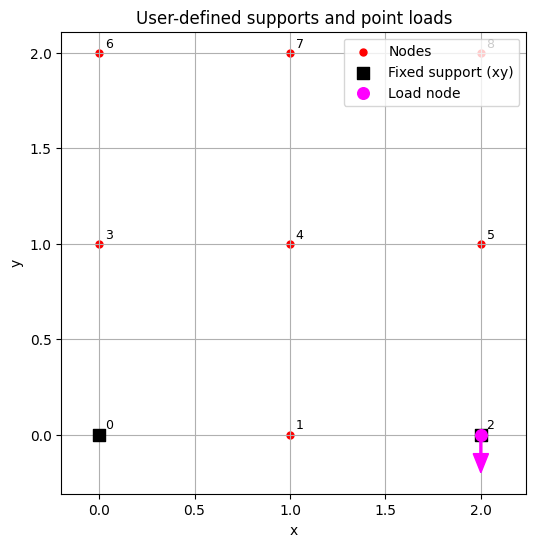

In [44]:
# 4.4 Plot the user-defined supports and  loads
plt.figure(figsize=(6, 6))

# Plot all nodes
plt.scatter(nodes[:, 0], nodes[:, 1], color="red", s=25, label="Nodes")

# Plot node labels
for i, (x_coord, y_coord) in enumerate(nodes):
    plt.text(x_coord + 0.03, y_coord + 0.03, str(i), fontsize=9)

# Plot supports
for s in supports:
    node = s["node"]
    x_coord, y_coord = nodes[node]

    if s["fix_x"] and s["fix_y"]:
        plt.scatter(x_coord, y_coord, color="black", marker="s", s=80, zorder=5,
                    label="Fixed support (xy)")
    elif s["fix_x"]:
        plt.scatter(x_coord, y_coord, color="blue", marker=">", s=90, zorder=5,
                    label="x restrained")
    elif s["fix_y"]:
        plt.scatter(x_coord, y_coord, color="green", marker="^", s=90, zorder=5,
                    label="y restrained")

# Plot loads as arrows
for load in loads:
    node = load["node"]
    Fx = load["Fx"]
    Fy = load["Fy"]

    x_coord, y_coord = nodes[node]

    plt.scatter(x_coord, y_coord, color="magenta", s=70, zorder=6, label="Load node")

    plt.arrow(
        x_coord, y_coord,
        0.2 * Fx, 0.2 * Fy,   # scale factor for visualization
        width=0.01,
        head_width=0.08,
        head_length=0.10,
        color="magenta",
        length_includes_head=True,
        zorder=7
    )

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.axis("equal")
plt.grid(True)
plt.title("User-defined supports and point loads")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 5. Reduced linear system

### 5.1 Build the reduced linear system

The reduced equilibrium matrix is obtained by selecting only the free degrees of freedom from the full equilibrium matrix.

The reduced load vector is formed consistently from the full load vector using the same set of free degrees of freedom.

In [45]:
# Build the reduced equilibrium matrix from the full matrix
A = A_full[free_dofs, :]

# Build the reduced load vector from the full load vector
b = b_full[free_dofs]

print("Shape of reduced A:", A.shape)
print("Shape of reduced b:", b.shape)

print("\nReduced load vector b:")
print(b)

print("\nRight-hand side -b:")
print(-b)

Shape of reduced A: (14, 36)
Shape of reduced b: (14,)

Reduced load vector b:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Right-hand side -b:
[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]


### 5.2 Final linear system

After assembling the global equilibrium matrix and applying the user-defined support conditions and point loads, the reduced system is obtained as

$$
Ax=-b
$$

where:
- $A$ is the reduced equilibrium matrix,
- $x$ is the vector of unknown axial member forces,
- $b$ is the reduced external nodal load vector.

This output verifies the dimensions of the reduced equilibrium system. The matrix \(A\) has one row for each free equilibrium equation and one column for each candidate member force. The vector \(x\) contains the unknown axial member forces, and \(b\) is the reduced load vector.

In [46]:
print("Final linear system:")
print(f"A shape = {A.shape}")
print(f"x shape = ({n_members},)")
print(f"b shape = {b.shape}")
print("\nThe equilibrium system is: A x = -b")

Final linear system:
A shape = (14, 36)
x shape = (36,)
b shape = (14,)

The equilibrium system is: A x = -b


### 5.3 Sanity check

As a basic verification step, the dimensions of the reduced equilibrium matrix and the reduced load vector are checked for consistency.

In [47]:
print("Number of nodes =", n_nodes)
print("Number of members =", n_members)
print("Number of constrained DOFs =", len(constrained_dofs))
print("Number of free DOFs =", len(free_dofs))

assert A.shape[0] == len(free_dofs)
assert A.shape[1] == n_members
assert b.shape[0] == len(free_dofs)

print("\nAll consistency checks passed.")

Number of nodes = 9
Number of members = 36
Number of constrained DOFs = 4
Number of free DOFs = 14

All consistency checks passed.


### 5.4 Optional matrix printout

For small benchmark cases such as 2x2, 3x3, or 4x4, the reduced equilibrium matrix \(A\), the reduced load vector \(b\), and the right-hand side \((-b)\) can be printed explicitly to allow manual checking of the entries.

In [48]:
# Matrix printout for small cases
np.set_printoptions(precision=4, suppress=True)

if n_rows <= 4 and n_cols <= 4:
    print("Nodes:")
    for i, xy in enumerate(nodes):
        print(f"{i}: {xy}")

    print("\nMembers (column order in A):")
    for k, m in enumerate(members):
        print(f"{k}: {m}")

    print("\nReduced equilibrium matrix A:")
    print(A)

    print("\nReduced load vector b:")
    print(b)

    print("\nRight-hand side -b:")
    print(-b)
else:
    print("Grid is larger than 4x4, so full matrix printout is skipped.")
    print("Use a 2x2, 3x3, or 4x4 case for manual verification.")

Nodes:
0: [0. 0.]
1: [1. 0.]
2: [2. 0.]
3: [0. 1.]
4: [1. 1.]
5: [2. 1.]
6: [0. 2.]
7: [1. 2.]
8: [2. 2.]

Members (column order in A):
0: (0, 1)
1: (0, 2)
2: (0, 3)
3: (0, 4)
4: (0, 5)
5: (0, 6)
6: (0, 7)
7: (0, 8)
8: (1, 2)
9: (1, 3)
10: (1, 4)
11: (1, 5)
12: (1, 6)
13: (1, 7)
14: (1, 8)
15: (2, 3)
16: (2, 4)
17: (2, 5)
18: (2, 6)
19: (2, 7)
20: (2, 8)
21: (3, 4)
22: (3, 5)
23: (3, 6)
24: (3, 7)
25: (3, 8)
26: (4, 5)
27: (4, 6)
28: (4, 7)
29: (4, 8)
30: (5, 6)
31: (5, 7)
32: (5, 8)
33: (6, 7)
34: (6, 8)
35: (7, 8)

Reduced equilibrium matrix A:
[[-1.      0.      0.      0.      0.      0.      0.      0.      1.
  -0.7071  0.      0.7071 -0.4472  0.      0.4472  0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [-0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.7071  1.      0.7071  0.8944  1.      0.8944  0.      0.      0.
   0.      0.      0. 

## 6. LP Objective Construction
This code constructs the linear programming (LP) objective function in standard form.

Starting from the force-based formulation, the objective is:

$$
\min \sum_{\{i,j\}\in A} l_{ij}\left(\frac{x_{ij}^{(+)}}{\sigma_t}+\frac{x_{ij}^{(-)}}{\sigma_c}\right)
$$


where: 
- $x_{ij}^{(+)}$ and $x_{ij}^{(-)}$ are the tension and compression parts of the member force


To allow different weighting of tension and compression members, separate allowable stresses are introduced:

$$
\sigma_t \quad \text{for tension}, \qquad \sigma_c \quad \text{for compression}.
$$

This means that tension and compression are penalized differently in the LP objective.



### 6.1 Standard LP Form the decision vector is

$$
z = [x^{(+)}, x^{(-)}]
$$

and the objective vector is

$$
c = [w^{(+)}, w^{(-)}],
$$

with the obejctive coefficents

$$
w^{(+)}_{ij}=\frac{l_{ij}}{\sigma_t},
\qquad
w^{(-)}_{ij}=\frac{l_{ij}}{\sigma_c}.
$$

### 6.2 Objective coefficients


In [49]:
# Member lengths
l = lengths.copy()

sigma_t = 1.0
ratio_tc = ask_float("Enter compression-to-tension stress ratio sigma_c / sigma_t: ")

if ratio_tc <= 0:
    raise ValueError("The ratio must be positive.")

sigma_c = ratio_tc * sigma_t

# Objective coefficients for tension and compression
w_plus = l / sigma_t     # tension part
w_minus = l / sigma_c    # compression part

n_members = len(l)
n_vars = 2 * n_members

# LP objective vector
c = np.concatenate([w_plus, w_minus])

print("Shape of l:", l.shape)
print("First 10 member lengths:")
print(l[:10])

print("\nShape of w_plus:", w_plus.shape)
print("First 10 tension coefficients:")
print(w_plus[:10])

print("\nShape of w_minus:", w_minus.shape)
print("First 10 compression coefficients:")
print(w_minus[:10])

print("\nShape of c:", c.shape)
print("First 20 entries of c:")
print(c[:20])

Enter compression-to-tension stress ratio sigma_c / sigma_t:  1


Shape of l: (36,)
First 10 member lengths:
[1.     2.     1.     1.4142 2.2361 2.     2.2361 2.8284 1.     1.4142]

Shape of w_plus: (36,)
First 10 tension coefficients:
[1.     2.     1.     1.4142 2.2361 2.     2.2361 2.8284 1.     1.4142]

Shape of w_minus: (36,)
First 10 compression coefficients:
[1.     2.     1.     1.4142 2.2361 2.     2.2361 2.8284 1.     1.4142]

Shape of c: (72,)
First 20 entries of c:
[1.     2.     1.     1.4142 2.2361 2.     2.2361 2.8284 1.     1.4142
 1.     1.4142 2.2361 2.     2.2361 2.2361 1.4142 1.     2.8284 2.2361]


### 6.3 Equality matrix

The reduced equilibrium system is already available in the form

$$
Ax = -b
$$

with the chosen sign convention.

Using the split variables, this becomes

$$
A\left(x^{(+)} - x^{(-)}\right) = -b
$$

which leads to the LP equality matrix

$$
A_{\mathrm{eq}} = [A,\,-A].
$$

In [50]:
A_eq = np.hstack([A, -A])

print("Shape of A:", A.shape)
print("Shape of A_eq:", A_eq.shape)

print("\nTop-left block of A_eq:")
print(A_eq[:6, :8])

Shape of A: (14, 36)
Shape of A_eq: (14, 72)

Top-left block of A_eq:
[[-1.      0.      0.      0.      0.      0.      0.      0.    ]
 [-0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.     -0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.     -1.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.     -0.7071  0.      0.      0.      0.    ]
 [ 0.      0.      0.     -0.7071  0.      0.      0.      0.    ]]


### 6.4 Right-hand side

The reduced load vector from the previous section is reused here and denoted by \(b\).

With the chosen sign convention, the LP right-hand side is

$$
b_{\mathrm{eq}} = -b.
$$

In [51]:
# LP right-hand side
b_eq = -b.copy()

print("Shape of b:", b.shape)
print("Shape of b_eq:", b_eq.shape)

print("\nb_eq:")
print(b_eq)

Shape of b: (14,)
Shape of b_eq: (14,)

b_eq:
[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]


### 6.5 Variable bounds

Both split variables are non-negative:

$$
x_{ij}^{(+)} \ge 0, \qquad x_{ij}^{(-)} \ge 0.
$$

Therefore, all LP variables have lower bound \(0\) and no upper bound.

In [52]:
bounds = [(0, None)] * n_vars

print("Number of bounds:", len(bounds))

Number of bounds: 72


### 6.6 Consistency check

Verify that the dimensions of the objective vector, equality matrix, and right-hand side are consistent.

In [53]:
print("A shape   :", A.shape)
print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)
print("c shape   :", c.shape)

assert A_eq.shape[1] == c.shape[0], "Mismatch: columns of A_eq must match length of c"
assert A_eq.shape[0] == b_eq.shape[0], "Mismatch: rows of A_eq must match length of b_eq"

print("\nDimension check passed.")

A shape   : (14, 36)
A_eq shape: (14, 72)
b_eq shape: (14,)
c shape   : (72,)

Dimension check passed.


## 7 Solve the LP

In this step, the linear programming problem is passed to the solver `scipy.optimize.linprog`.

The solver receives the LP in standard form:

$$
\min \; c^T z
$$

subject to

$$
A_{\mathrm{eq}} z = b_{\mathrm{eq}}
$$

and

$$
z \ge 0
$$

where:
- $c$ is the objective vector,
- $A_eq$ is the equality matrix,
- $b_eq$ is the right-hand side vector,
- and `bounds` specifies that all variables are non-negative.

The option `"highs"` selects the HiGHS solver, which is a modern and efficient LP solver implemented in SciPy.

In [54]:
from scipy.optimize import linprog

result = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

print("Solver success:", result.success)
print("Solver message:", result.message)
print("Optimal objective value:", result.fun)

Solver success: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal objective value: 0.0


### 7.1 Recover member forces

The LP solver returns the split variables \(x^{(+)}\) and \(x^{(-)}\), which were introduced to replace the signed force variable by two non-negative variables.

To obtain the actual axial member force of each bar, the compression part is subtracted from the tension part:

$$
x = x^{(+)} - x^{(-)}.
$$

This recovers the signed internal force:
- $x > 0$: member in tension
- $x < 0$: member in compression
- $x = 0$: inactive member

In [55]:
if result.x is None:
    raise ValueError("LP solver did not return a solution vector.")

z = result.x

x_plus = z[:n_members]
x_minus = z[n_members:]
x = x_plus - x_minus

print("Shape of x:", x.shape)
print("First 10 x_plus:")
print(x_plus[:10])

print("\nFirst 10 x_minus:")
print(x_minus[:10])

print("\nFirst 10 reconstructed member forces:")
print(x[:10])

Shape of x: (36,)
First 10 x_plus:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 x_minus:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 reconstructed member forces:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 7.2 Recover cross-sectional areas

Since different allowable stresses are used for tension and compression, the cross-sectional area is recovered depending on the sign of the member force:

$$
a_{ij}=
\begin{cases}
\dfrac{x_{ij}}{\sigma_t}, & x_{ij}\ge 0,\\[1ex]
\dfrac{-x_{ij}}{\sigma_c}, & x_{ij}<0.
\end{cases}
$$

In [56]:
a = np.zeros_like(x)
a[x >= 0] = x[x >= 0] / sigma_t
a[x < 0] = (-x[x < 0]) / sigma_c

### 7.3 Check equilibrium residual

As a verification step, the reconstructed member force vector is inserted back into the reduced equilibrium equations.  
The residual should be close to zero up to numerical tolerance.

In [57]:
residual = A @ x - b_eq

print("Residual norm:", np.linalg.norm(residual))
print("Residual vector:")
print(residual)

Residual norm: 0.0
Residual vector:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 7.4 Identify active members

Members with force close to zero are considered inactive and can be interpreted as removed from the final optimized structure.

In [ ]:
tol = 1e-9
active = np.abs(x) > tol

print("Number of active members:", np.sum(active))
print("Active member indices:")
print(np.where(active)[0])

## 8. Plot the optimized structure

In this step, the optimized structure obtained from the LP solver is visualized.

Only members with non-zero axial force are plotted as active members.  
Optionally, the line width is scaled with the recovered cross-sectional areas.

### 8.1 Active members

In [ ]:
plt.figure(figsize=(9, 4))

# Plot all candidate members in light gray
for i, j in members:
    xi, yi = nodes[i]
    xj, yj = nodes[j]
    plt.plot([xi, xj], [yi, yj], color="lightgray", linewidth=0.3)

# Plot active members
for k, (i, j) in enumerate(members):
    if active[k]:
        xi, yi = nodes[i]
        xj, yj = nodes[j]
        plt.plot([xi, xj], [yi, yj], color="black", linewidth=2.0)

# Plot nodes
plt.scatter(nodes[:, 0], nodes[:, 1], s=15, color="red")

plt.axis("equal")
plt.xlim(-0.3, np.max(nodes[:, 0]) + 0.5)
plt.ylim(-0.3, np.max(nodes[:, 1]) + 0.5)
plt.xticks(np.arange(0, n_cols * dx, dx))
plt.yticks(np.arange(0, n_rows * dy, dy))
plt.grid(True)
plt.title("Optimized structure (active members only)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 8.2 Line thickness according to cross-section


In [ ]:

plt.figure(figsize=(9, 4))

# Plot all candidate members in light gray
for i, j in members:
    xi, yi = nodes[i]
    xj, yj = nodes[j]
    plt.plot([xi, xj], [yi, yj], color="lightgray", linewidth=0.3)

# Maximum area for scaling
a_max = np.max(a) if np.max(a) > 0 else 1.0

# Plot active members with linewidth scaled by cross-sectional area
for k, (i, j) in enumerate(members):
    if active[k]:
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        lw = 0.5 + 4.0 * (a[k] / a_max)
        plt.plot([xi, xj], [yi, yj], color="black", linewidth=lw)

# Plot nodes
plt.scatter(nodes[:, 0], nodes[:, 1], s=15, color="red")

plt.axis("equal")
plt.xlim(-0.3, np.max(nodes[:, 0]) + 0.5)
plt.ylim(-0.3, np.max(nodes[:, 1]) + 0.5)
plt.xticks(np.arange(0, n_cols * dx, dx))
plt.yticks(np.arange(0, n_rows * dy, dy))
plt.grid(True)
plt.title("Optimized structure (linewidth scaled by area)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 8.3 Distinguish between tension and comression

In [ ]:

plt.figure(figsize=(9, 4))

# Plot all candidate members in light gray
for i, j in members:
    xi, yi = nodes[i]
    xj, yj = nodes[j]
    plt.plot([xi, xj], [yi, yj], color="lightgray", linewidth=0.3)

a_max = np.max(a) if np.max(a) > 0 else 1.0

for k, (i, j) in enumerate(members):
    if active[k]:
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        lw = 0.5 + 4.0 * (a[k] / a_max)

        if x[k] > 0:
            color = "red"      # tension
        else:
            color = "blue"    # compression

        plt.plot([xi, xj], [yi, yj], color=color, linewidth=lw)

# Plot nodes
plt.scatter(nodes[:, 0], nodes[:, 1], s=15, color="red")

plt.axis("equal")
plt.xlim(-0.3, np.max(nodes[:, 0]) + 0.5)
plt.ylim(-0.3, np.max(nodes[:, 1]) + 0.5)
plt.xticks(np.arange(0, n_cols * dx, dx))
plt.yticks(np.arange(0, n_rows * dy, dy))
plt.grid(True)
plt.title("Optimized structure (red = tension, blue = compression)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 8.4 Final plot: optimized structure with force type, member size, supports, and loads

The final optimized structure is visualized by combining several types of information:

- only active members are shown,
- the line width is scaled according to the recovered cross-sectional area,
- the color indicates whether a member is in tension or compression,
- the user-defined support conditions are highlighted,
- and the user-defined point loads are shown together with their directions.

In [ ]:
plt.figure(figsize=(12, 5))

# Plot all candidate members in light gray
for i, j in members:
    xi, yi = nodes[i]
    xj, yj = nodes[j]
    plt.plot([xi, xj], [yi, yj], color="lightgray", linewidth=0.3)

a_max = np.max(a) if np.max(a) > 0 else 1.0

# Plot active members
for k, (i, j) in enumerate(members):
    if np.abs(x[k]) > tol:
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        lw = 0.5 + 4.0 * (a[k] / a_max)
        color = "red" if x[k] > 0 else "blue"

        plt.plot([xi, xj], [yi, yj], color=color, linewidth=lw, zorder=2)

# Plot all nodes
plt.scatter(nodes[:, 0], nodes[:, 1], s=15, color="black", zorder=3)

# Plot supports from the user-defined support list
for s in supports:
    node = s["node"]
    x_coord, y_coord = nodes[node]

    if s["fix_x"] and s["fix_y"]:
        plt.scatter(x_coord, y_coord, color="brown", marker="s", s=70,
                    label="Fixed support (xy)", zorder=4)
    elif s["fix_x"]:
        plt.scatter(x_coord, y_coord, color="brown", marker=">", s=80,
                    label="x restrained", zorder=4)
    elif s["fix_y"]:
        plt.scatter(x_coord, y_coord, color="green", marker="^", s=80,
                    label="y restrained", zorder=4)

# Plot loads from the user-defined load list
for load in loads:
    node = load["node"]
    Fx = load["Fx"]
    Fy = load["Fy"]

    x_coord, y_coord = nodes[node]

    plt.scatter(x_coord, y_coord, color="black", s=80, label="Load node", zorder=5)

    plt.arrow(
    x_coord, y_coord,
    0.2 * Fx, 0.2 * Fy,   # longer arrow
    width=0.02,          # thicker shaft
    head_width=0.08,      # wider head
    head_length=0.08,     # longer head
    color="green",
    length_includes_head=True,
    zorder=6
    )

# Legend helpers for member force type
plt.plot([], [], color="red", linewidth=2, label="Tension")
plt.plot([], [], color="blue", linewidth=2, label="Compression")

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.axis("equal")
plt.xlim(-0.3, np.max(nodes[:, 0]) + 0.5)
plt.ylim(-0.3, np.max(nodes[:, 1]) + 0.5)
plt.grid(True)
plt.title("Final optimized structure")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("final_plot.png", dpi=300, bbox_inches="tight")
plt.savefig("final_plot.pdf", bbox_inches="tight")
plt.show()

### 8.5 Debug plot with member force and length

This plot is intended for debugging and interpretation.

For each active member, the midpoint label shows:
- the member length $l_{ij}$,
- the recovered axial force $x_{ij}$.

The user-defined support conditions and point loads are also visualized.

In [ ]:
plt.figure(figsize=(12, 5))

a_max = np.max(a) if np.max(a) > 0 else 1.0

for k, (i, j) in enumerate(members):
    if np.abs(x[k]) > tol:
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        lw = 0.5 + 4.0 * (a[k] / a_max)
        color = "red" if x[k] > 0 else "blue"

        plt.plot([xi, xj], [yi, yj], color=color, linewidth=lw, zorder=2)

        # Midpoint
        xm = 0.5 * (xi + xj)
        ym = 0.5 * (yi + yj)

        # Small offset normal to the member
        dxm = xj - xi
        dym = yj - yi
        norm = np.sqrt(dxm**2 + dym**2)

        if norm > 0:
            nx = -dym / norm
            ny = dxm / norm
        else:
            nx, ny = 0.0, 0.0

        offset = 0.10
        xm_text = xm + offset * nx
        ym_text = ym + offset * ny

        label = f"l={l[k]:.2f}\nx={x[k]:.2f}"

        plt.text(
            xm_text,
            ym_text,
            label,
            fontsize=8,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
            zorder=5
        )

# Plot all nodes
plt.scatter(nodes[:, 0], nodes[:, 1], s=15, color="black", zorder=3)

# Plot supports
for s in supports:
    node = s["node"]
    x_coord, y_coord = nodes[node]

    if s["fix_x"] and s["fix_y"]:
        plt.scatter(x_coord, y_coord, color="brown", marker="s", s=70,
                    label="Fixed support (xy)", zorder=4)
    elif s["fix_x"]:
        plt.scatter(x_coord, y_coord, color="blue", marker=">", s=80,
                    label="x restrained", zorder=4)
    elif s["fix_y"]:
        plt.scatter(x_coord, y_coord, color="green", marker="^", s=80,
                    label="y restrained", zorder=4)

# Plot loads
for load in loads:
    node = load["node"]
    Fx = load["Fx"]
    Fy = load["Fy"]

    x_coord, y_coord = nodes[node]

    plt.scatter(x_coord, y_coord, color="black", s=80, label="Load node", zorder=6)

    plt.arrow(
        x_coord, y_coord,
        0.2 * Fx, 0.2 * Fy,
        width=0.01,
        head_width=0.08,
        head_length=0.10,
        color="green",
        length_includes_head=True,
        zorder=6
    )

# Legend helpers
plt.plot([], [], color="red", linewidth=2, label="Tension")
plt.plot([], [], color="blue", linewidth=2, label="Compression")

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.axis("equal")
plt.xlim(-0.3, np.max(nodes[:, 0]) + 0.5)
plt.ylim(-0.3, np.max(nodes[:, 1]) + 0.5)
plt.grid(True)
plt.title("Debug plot: optimized structure with member annotations")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 9. Synthetic inventory definition

To prepare the transition from the continuous LP baseline to a stock-constrained design formulation, a small synthetic inventory is introduced.

At this stage, the inventory is defined only by:
- a stock type identifier,
- a cross-sectional area,
- and the available quantity of that stock type.

This keeps the first extension minimal and manageable, while already introducing the idea of limited discrete resources.

### 9.1 Define a synthetic inventory

Each stock type is described by:
- `stock_id`: identifier of the stock type,
- `area`: available cross-sectional area,
- `count`: number of available members of this type.

For now, the inventory is synthetic, meaning that it is created manually for testing purposes.

In [18]:
# Synthetic inventory for first stock-constrained tests
inventory = [
    {"stock_id": 0, "area": 0.5, "count": 4},
    {"stock_id": 1, "area": 1.0, "count": 3},
    {"stock_id": 2, "area": 2.0, "count": 2},
]

print("Synthetic inventory:")
for item in inventory:
    print(item)

Synthetic inventory:
{'stock_id': 0, 'area': 0.5, 'count': 4}
{'stock_id': 1, 'area': 1.0, 'count': 3}
{'stock_id': 2, 'area': 2.0, 'count': 2}


### 9.2 Convert the inventory into arrays

For later optimization steps, the inventory data is converted into NumPy arrays.

This makes it easier to use the stock data in matrix-based formulations and solver calls.

In [19]:
# Extract inventory information into arrays
stock_ids = np.array([item["stock_id"] for item in inventory], dtype=int)
stock_areas = np.array([item["area"] for item in inventory], dtype=float)
stock_counts = np.array([item["count"] for item in inventory], dtype=int)

n_stock_types = len(inventory)

print("stock_ids    =", stock_ids)
print("stock_areas  =", stock_areas)
print("stock_counts =", stock_counts)
print("Number of stock types =", n_stock_types)

print("Inventory overview:")
print("stock_id | area | count")
for s, a_s, q_s in zip(stock_ids, stock_areas, stock_counts):
    print(f"{s:8d} | {a_s:4.2f} | {q_s:5d}")

stock_ids    = [0 1 2]
stock_areas  = [0.5 1.  2. ]
stock_counts = [4 3 2]
Number of stock types = 3
Inventory overview:
stock_id | area | count
       0 | 0.50 |     4
       1 | 1.00 |     3
       2 | 2.00 |     2


### 9.3 Basic inventory sanity check

Before using the inventory in a stock-constrained formulation, the data is checked for consistency.

In particular:
- all areas must be positive,
- all counts must be non-negative,
- and the number of stock types must be at least one.

In [20]:
assert n_stock_types >= 1, "The inventory must contain at least one stock type."
assert np.all(stock_areas > 0), "All stock areas must be positive."
assert np.all(stock_counts >= 0), "All stock counts must be non-negative."

print("Inventory sanity check passed.")

Inventory sanity check passed.


## 10. Minimal stock-aware formulation

The continuous LP baseline determines an ideal truss layout with continuous member areas recovered from the axial forces.
To move toward a stock-constrained design, the next step is to replace these continuous areas by discrete choices from a finite inventory.
The purpose is to define the new stock-aware variables and prepare the data structures required for the next implementation step.

### 10.1 Stock assignment variables

Let the synthetic inventory contain a finite set of stock types

$$
S = \{1,2,\dots,n_{\mathrm{stock}}\}.
$$

Each stock type $s \in S$ has:
- a cross-sectional area $\bar a_s$,
- and an available quantity $q_s$.

To assign a stock type to a member $\{i,j\} \in A$, introduce the binary variable

$$
y_{ij}^s \in \{0,1\},
$$

where

$$
y_{ij}^s =
\begin{cases}
1, & \text{if member } \{i,j\} \text{ uses stock type } s,\\
0, & \text{otherwise.}
\end{cases}
$$

These variables will later be used in the mixed-integer extension of the LP baseline.

### 10.2 Inventory-based member areas

Once the binary stock assignment variables are introduced, the member area is no longer a free continuous quantity.

Instead, it is defined from the selected stock type as

$$
a_{ij} = \sum_{s \in S} \bar a_s \, y_{ij}^s.
$$

Thus, each member area is chosen from the finite set of available stock areas rather than being recovered as a fully continuous value.

To ensure that at most one stock type is assigned to a member, the following constraint will later be used:

$$
\sum_{s \in S} y_{ij}^s \le 1
\qquad \forall \{i,j\} \in A.
$$

### 10.3 Future stock-count constraints

The synthetic inventory also specifies how many members of each stock type are available.

If stock type $s$ is available only in quantity $q_s$, then the assignment variables must satisfy

$$
\sum_{\{i,j\} \in A} y_{ij}^s \le q_s
\qquad \forall s \in S.
$$

This is the key constraint that turns the design problem into a stock-constrained formulation.

In the first implementation step, these constraints are introduced conceptually and the corresponding data structures are prepared.

### 10.4 Strength constraints in the future MILP

In the continuous LP baseline, the member areas are recovered after solving the force problem.

In the future stock-aware mixed-integer formulation, the selected stock area must instead provide enough capacity for the member force.

Using the split force variables, this leads to the constraints

$$
x_{ij}^{(+)} \le \sigma_t \, a_{ij},
$$

$$
x_{ij}^{(-)} \le \sigma_c \, a_{ij},
$$

with

$$
a_{ij} = \sum_{s \in S} \bar a_s \, y_{ij}^s.
$$

These constraints link the continuous force variables to the discrete stock assignment variables.

### 10.5 Build stock-member indexing

To prepare the future mixed-integer formulation, all possible combinations of:
- candidate member $k$,
- and stock type $s$,

are enumerated.

This gives a clean indexing structure for the future binary stock-assignment variables.

In [21]:
# Build all member-stock combinations
member_stock_pairs = [] #empty list

for k in range(n_members): # double-loop
    for s in range(n_stock_types):
        member_stock_pairs.append((k, s))

n_member_stock_pairs = len(member_stock_pairs) #total amount of combinations

print("First 10 member-stock pairs:")
print(member_stock_pairs[:10])

print("\nNumber of candidate members =", n_members)
print("Number of stock types      =", n_stock_types)
print("Number of member-stock pairs =", n_member_stock_pairs)

First 10 member-stock pairs:
[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0)]

Number of candidate members = 36
Number of stock types      = 3
Number of member-stock pairs = 108


### 10.6 Group stock types by member

For each candidate member, the corresponding stock types are grouped together.

This will later be useful when enforcing that each member can be assigned at most one stock type.

In [22]:
# For each member k, store the list of stock types that could be assigned
stock_types_for_member = {} #empty dictionary

for k in range(n_members):
    stock_types_for_member[k] = list(range(n_stock_types))

print("Example: stock types available for first 5 members")
for k in range(min(5, n_members)):
    print(f"Member {k}: {stock_types_for_member[k]}")

Example: stock types available for first 5 members
Member 0: [0, 1, 2]
Member 1: [0, 1, 2]
Member 2: [0, 1, 2]
Member 3: [0, 1, 2]
Member 4: [0, 1, 2]


### 10.7 Group members by stock type

For each stock type, the corresponding candidate members are grouped together.

This will later be useful when enforcing the available quantity of each stock type.

In [23]:
# For each stock type s, store the list of members that could use it
members_for_stock_type = {}

for s in range(n_stock_types):
    members_for_stock_type[s] = list(range(n_members))

print("Example: first 3 stock types and their candidate members")
for s in range(min(3, n_stock_types)):
    print(f"Stock type {s}: first 10 members -> {members_for_stock_type[s][:10]}")

Example: first 3 stock types and their candidate members
Stock type 0: first 10 members -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Stock type 1: first 10 members -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Stock type 2: first 10 members -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 11. First stock-aware prototype model

This section defines the first solver-ready stock-aware extension of the LP baseline.

The purpose is to move from:
- continuous member areas recovered after solving,

to:
- discrete member areas selected from a finite inventory.

At this stage:
- the force variables remain continuous,
- the stock assignment variables become binary,
- and the member area is determined by the selected stock type.

This yields the first mixed-integer structure of the model.

### 11.1 Decision variables

The continuous force variables remain

$$
x_{ij}^{(+)} \ge 0, \qquad x_{ij}^{(-)} \ge 0,
$$

where:
- $x_{ij}^{(+)}$ is the tension part of the axial force,
- $x_{ij}^{(-)}$ is the compression part of the axial force.

To assign stock types to members, introduce the binary variables

$$
y_{ij}^s \in \{0,1\},
$$

with

$$
y_{ij}^s =
\begin{cases}
1, & \text{if member } \{i,j\} \text{ uses stock type } s,\\
0, & \text{otherwise.}
\end{cases}
$$

The member area is then defined by

$$
a_{ij} = \sum_{s \in S} \bar a_s \, y_{ij}^s.
$$

### 11.2 Objective function

In the stock-aware prototype, the member areas are no longer continuous free quantities.  
Instead, they are selected from the discrete inventory.

A natural linear objective is therefore to minimize the total used volume:

$$
\min \sum_{\{i,j\}\in A}\sum_{s \in S} l_{ij}\,\bar a_s\, y_{ij}^s.
$$

This differs from the force-based LP baseline, because the areas are now explicit discrete design choices.

### 11.3 Constraints

The stock-aware prototype uses the following constraints.

#### Equilibrium
The nodal equilibrium equations remain unchanged:

$$
A\left(x^{(+)} - x^{(-)}\right) = -b.
$$

#### Strength constraints
The selected stock area must provide enough capacity for the member force:

$$
x_{ij}^{(+)} \le \sigma_t \, a_{ij},
$$

$$
x_{ij}^{(-)} \le \sigma_c \, a_{ij},
$$

with

$$
a_{ij} = \sum_{s \in S} \bar a_s \, y_{ij}^s.
$$

#### At most one stock type per member
Each member can be assigned at most one stock type:

$$
\sum_{s \in S} y_{ij}^s \le 1
\qquad \forall \{i,j\} \in A.
$$

#### Inventory count constraints
The available quantity of each stock type is limited by the inventory:

$$
\sum_{\{i,j\} \in A} y_{ij}^s \le q_s
\qquad \forall s \in S.
$$

### 11.4 Variable ordering

To prepare the future mixed-integer implementation, all variables are collected in a single decision vector

$$
z = [x^{(+)}, x^{(-)}, y].
$$

The variable ordering is chosen as:
- first all tension force variables,
- then all compression force variables,
- then all binary stock-assignment variables.

This indexing structure will later be used to build the linear objective and constraint matrices.

In [24]:
# Number of continuous force variables
n_x_plus = n_members
n_x_minus = n_members

# Number of binary stock-assignment variables
n_y = n_member_stock_pairs

# Total number of decision variables
n_vars_stock = n_x_plus + n_x_minus + n_y

print("Number of x_plus variables =", n_x_plus)
print("Number of x_minus variables =", n_x_minus)
print("Number of y variables =", n_y)
print("Total number of stock-aware decision variables =", n_vars_stock)

Number of x_plus variables = 36
Number of x_minus variables = 36
Number of y variables = 108
Total number of stock-aware decision variables = 180


### 11.5 Variable index maps

To simplify the matrix assembly, explicit index maps are created for:
- the tension force variables,
- the compression force variables,
- and the binary stock-assignment variables.

In [25]:
# Index maps for the future decision vector z = [x_plus, x_minus, y]

x_plus_index = {}
x_minus_index = {}
y_index = {}

# x_plus variables
for k in range(n_members):
    x_plus_index[k] = k

# x_minus variables
for k in range(n_members):
    x_minus_index[k] = n_members + k

# y variables
# Loop over all member-stock pairs -> enumerate(...) gives two outputs for each iteration:
# 1) idx  -> the running counter starting from 0
# 2) (k,s) -> the actual pair from the list member_stock_pairs
for idx, (k, s) in enumerate(member_stock_pairs):
    y_index[(k, s)] = 2 * n_members + idx

print("Example x_plus indices:")
for k in range(min(5, n_members)):
    print(f"x_plus[{k}] -> {x_plus_index[k]}")

print("\nExample x_minus indices:")
for k in range(min(5, n_members)):
    print(f"x_minus[{k}] -> {x_minus_index[k]}")

print("\nExample y indices:")
for pair in member_stock_pairs[:10]:
    print(f"y{pair} -> {y_index[pair]}")

Example x_plus indices:
x_plus[0] -> 0
x_plus[1] -> 1
x_plus[2] -> 2
x_plus[3] -> 3
x_plus[4] -> 4

Example x_minus indices:
x_minus[0] -> 36
x_minus[1] -> 37
x_minus[2] -> 38
x_minus[3] -> 39
x_minus[4] -> 40

Example y indices:
y(0, 0) -> 72
y(0, 1) -> 73
y(0, 2) -> 74
y(1, 0) -> 75
y(1, 1) -> 76
y(1, 2) -> 77
y(2, 0) -> 78
y(2, 1) -> 79
y(2, 2) -> 80
y(3, 0) -> 81


### 11.6 Objective vector for the stock-aware model

In the stock-aware formulation, the force variables do not contribute directly to the objective.

Only the binary stock-assignment variables contribute, with coefficient

$$
l_{ij}\,\bar a_s.
$$

Thus, the objective vector contains:
- zeros for the force variables,
- and volume-based coefficients for the stock-assignment variables.

In [29]:
# Initialize full objective vector for z = [x_plus, x_minus, y]
c_stock = np.zeros(n_vars_stock)

# Add coefficients for y variables
for (k, s), idx in y_index.items():
    c_stock[idx] = lengths[k] * stock_areas[s]

print("Shape of c_stock:", c_stock.shape)
print("First 20 entries of c_stock:")
print(c_stock[:20])

print("\nFirst 10 nonzero stock-objective coefficients:")
nonzero_idx = np.nonzero(c_stock)[0]
print(c_stock[nonzero_idx[:10]])

Shape of c_stock: (180,)
First 20 entries of c_stock:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 nonzero stock-objective coefficients:
[0.5        1.         2.         1.         2.         4.
 0.5        1.         2.         0.70710678]


### 11.7 Member-area selection matrix

A matrix is constructed that maps the binary stock-assignment variables to the implied member areas.

For each member $k$, the corresponding row contains the available stock areas $\bar a_s$ in the columns associated with that member.

In [30]:
# Matrix that maps y variables to member areas
# Shape: (n_members, n_vars_stock)
# Only the y-part is filled, because x_plus and x_minus do not contribute directly to area

B_area = np.zeros((n_members, n_vars_stock))

for (k, s), idx in y_index.items():
    B_area[k, idx] = stock_areas[s]

print("Shape of B_area:", B_area.shape)
print("Top-left corner of B_area:")
print(B_area[:5, 2 * n_members : 2 * n_members + min(10, n_y)])

Shape of B_area: (36, 180)
Top-left corner of B_area:
[[0.5 1.  2.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.5 1.  2.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.5 1.  2.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]]


### 11.8 Strength-constraint matrices

To prepare the future mixed-integer solve, matrices are built for the strength constraints

$$
x_k^{(+)} - \sigma_t \sum_s \bar a_s y_{k,s} \le 0,
$$

$$
x_k^{(-)} - \sigma_c \sum_s \bar a_s y_{k,s} \le 0.
$$

These constraints link the continuous force variables to the discrete stock-assignment variables.

In [58]:
# Tension capacity constraints: x_plus - sigma_t * area <= 0
A_tension_cap = np.zeros((n_members, n_vars_stock))
b_tension_cap = np.zeros(n_members)

for k in range(n_members):
    A_tension_cap[k, x_plus_index[k]] = 1.0

for k in range(n_members):
    for s in range(n_stock_types):
        idx = y_index[(k, s)]
        A_tension_cap[k, idx] -= sigma_t * stock_areas[s]

# Compression capacity constraints: x_minus - sigma_c * area <= 0
A_compression_cap = np.zeros((n_members, n_vars_stock))
b_compression_cap = np.zeros(n_members)

for k in range(n_members):
    A_compression_cap[k, x_minus_index[k]] = 1.0

for k in range(n_members):
    for s in range(n_stock_types):
        idx = y_index[(k, s)]
        A_compression_cap[k, idx] -= sigma_c * stock_areas[s]

print("Shape of A_tension_cap:", A_tension_cap.shape)
print("Shape of A_compression_cap:", A_compression_cap.shape)

Shape of A_tension_cap: (36, 180)
Shape of A_compression_cap: (36, 180)


### 11.9 Member assignment constraints

Each member can be assigned at most one stock type:

$$
\sum_{s \in S} y_k^s \le 1.
$$

A matrix is built to represent this constraint for all candidate members.
                                              

In [59]:
# At most one stock type per member
A_member_assign = np.zeros((n_members, n_vars_stock))
b_member_assign = np.ones(n_members)

for k in range(n_members):
    for s in range(n_stock_types):
        idx = y_index[(k, s)]
        A_member_assign[k, idx] = 1.0

print("Shape of A_member_assign:", A_member_assign.shape)
print("First 5 rows of y-part:")
print(A_member_assign[:5, 2 * n_members : 2 * n_members + min(10, n_y)])

Shape of A_member_assign: (36, 180)
First 5 rows of y-part:
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### 11.10 Inventory count constraints

The number of members assigned to stock type \(s\) must not exceed the available quantity \(q_s\):

$$
\sum_k y_k^s \le q_s.
$$

A matrix is built to represent these inventory limits.

In [60]:
# Inventory count constraints
A_stock_count = np.zeros((n_stock_types, n_vars_stock))
b_stock_count = stock_counts.astype(float).copy()

for s in range(n_stock_types):
    for k in range(n_members):
        idx = y_index[(k, s)]
        A_stock_count[s, idx] = 1.0

print("Shape of A_stock_count:", A_stock_count.shape)
print("b_stock_count =", b_stock_count)
print("First rows of y-part:")
print(A_stock_count[:, 2 * n_members : 2 * n_members + min(12, n_y)])

Shape of A_stock_count: (3, 180)
b_stock_count = [4. 3. 2.]
First rows of y-part:
[[1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]]


### 11.11 Equilibrium matrix in stock-aware variable space

The equilibrium equations remain unchanged.

In the full variable vector

$$
z = [x^{(+)}, x^{(-)}, y],
$$

the equilibrium matrix becomes

$$
A_{\mathrm{eq,stock}} = [A,\,-A,\,0].
$$

The binary stock-assignment variables do not appear directly in equilibrium.

In [61]:
# Equilibrium matrix in full stock-aware variable space
A_eq_stock = np.hstack([
    A,
    -A,
    np.zeros((A.shape[0], n_y))
])

b_eq_stock = -b.copy()

print("Shape of A_eq_stock:", A_eq_stock.shape)
print("Shape of b_eq_stock:", b_eq_stock.shape)

Shape of A_eq_stock: (14, 180)
Shape of b_eq_stock: (14,)


### 11.12 Summary of prepared model blocks

At this stage, the following model components are available:

- objective vector for the stock-aware decision vector,
- equilibrium matrix,
- strength-constraint matrices,
- member-assignment constraints,
- inventory-count constraints.

The model is now structurally ready for the first mixed-integer solver call.

In [62]:
print("Prepared stock-aware model blocks:")
print("c_stock shape           =", c_stock.shape)
print("A_eq_stock shape        =", A_eq_stock.shape)
print("b_eq_stock shape        =", b_eq_stock.shape)
print("A_tension_cap shape     =", A_tension_cap.shape)
print("A_compression_cap shape =", A_compression_cap.shape)
print("A_member_assign shape   =", A_member_assign.shape)
print("A_stock_count shape     =", A_stock_count.shape)


Prepared stock-aware model blocks:
c_stock shape           = (180,)
A_eq_stock shape        = (14, 180)
b_eq_stock shape        = (14,)
A_tension_cap shape     = (36, 180)
A_compression_cap shape = (36, 180)
A_member_assign shape   = (36, 180)
A_stock_count shape     = (3, 180)


## 12. First mixed-integer solve

In this section, the prepared stock-aware model is passed to a mixed-integer linear programming solver.

The decision vector is

$$
z = [x^{(+)}, x^{(-)}, y],
$$

where:
- $x^{(+)}$ and $x^{(-)}$ are continuous force variables,
- $y$ contains the binary stock-assignment variables.

The mixed-integer solve is first tested on a very small benchmark case.

### 12.1 Import the mixed-integer solver tools

The stock-aware prototype is solved using `scipy.optimize.milp`, together with `LinearConstraint` and `Bounds`.

In [63]:
from scipy.optimize import milp, LinearConstraint, Bounds

### 12.2 Equality constraints

The equilibrium equations are represented as equality constraints in the mixed-integer model:

$$
A_{\mathrm{eq,stock}} z = b_{\mathrm{eq,stock}}.
$$

In [64]:
eq_constraints = LinearConstraint(
    A_eq_stock,
    lb=b_eq_stock,
    ub=b_eq_stock
)

print("Equality constraints created.")
print("A_eq_stock shape =", A_eq_stock.shape)
print("b_eq_stock shape =", b_eq_stock.shape)

Equality constraints created.
A_eq_stock shape = (14, 180)
b_eq_stock shape = (14,)


### 12.3 Inequality constraints

The stock-aware model uses the following inequality constraints:

- tension capacity constraints,
- compression capacity constraints,
- at-most-one-stock-type-per-member constraints,
- inventory count constraints.

In [65]:
tension_constraints = LinearConstraint(
    A_tension_cap,
    lb=-np.inf * np.ones_like(b_tension_cap),
    ub=b_tension_cap
)

compression_constraints = LinearConstraint(
    A_compression_cap,
    lb=-np.inf * np.ones_like(b_compression_cap),
    ub=b_compression_cap
)

member_assign_constraints = LinearConstraint(
    A_member_assign,
    lb=-np.inf * np.ones_like(b_member_assign),
    ub=b_member_assign
)

stock_count_constraints = LinearConstraint(
    A_stock_count,
    lb=-np.inf * np.ones_like(b_stock_count),
    ub=b_stock_count
)

print("Inequality constraints created.")

Inequality constraints created.


### 12.4 Variable bounds

The force variables are non-negative, and the binary stock-assignment variables are bounded between 0 and 1.

In [66]:
lower_bounds = np.zeros(n_vars_stock)
upper_bounds = np.full(n_vars_stock, np.inf)

# Binary variables y must satisfy 0 <= y <= 1
for (k, s), idx in y_index.items():
    upper_bounds[idx] = 1.0

bounds_stock = Bounds(lower_bounds, upper_bounds)

print("Bounds created.")
print("Number of variables =", n_vars_stock)

Bounds created.
Number of variables = 180


### 12.5 Integrality vector

The force variables remain continuous, while the stock-assignment variables are binary.

Therefore:
- the entries corresponding to \(x^{(+)}\) and \(x^{(-)}\) are continuous,
- the entries corresponding to \(y\) are integral.

In [67]:
integrality = np.zeros(n_vars_stock, dtype=int)

# Set y variables as integer
for (k, s), idx in y_index.items():
    integrality[idx] = 1

print("Integrality vector created.")
print("Number of integer variables =", np.sum(integrality == 1))
print("Number of continuous variables =", np.sum(integrality == 0))

Integrality vector created.
Number of integer variables = 108
Number of continuous variables = 72


### 12.6 Collect all constraints

All equality and inequality constraints are collected into a single list for the mixed-integer solver.

In [68]:
constraints_stock = [
    eq_constraints,
    tension_constraints,
    compression_constraints,
    member_assign_constraints,
    stock_count_constraints
]

print("Total number of constraint blocks =", len(constraints_stock))

Total number of constraint blocks = 5


### 12.7 Solve the stock-aware mixed-integer problem

The mixed-integer stock-aware prototype is now solved.

Since this is the first prototype solve, it is recommended to test it only on a very small benchmark case.

In [70]:
result_stock = milp(
    c=c_stock,
    integrality=integrality,
    bounds=bounds_stock,
    constraints=constraints_stock,
    options={
        "disp": True,
        "presolve": True,
        "time_limit": 60.0,
        "mip_rel_gap": 1e-6,
    }
)

print("MILP success:", result_stock.success)
print("MILP status:", result_stock.status)
print("MILP message:", result_stock.message)
print("MILP objective value:", result_stock.fun)

Running HiGHS 1.2.0 [date: 2021-07-09, git hash: n/a]
Copyright (c) 2022 ERGO-Code under MIT licence terms
MILP success: True
MILP status: 0
MILP message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
MILP objective value: 0.0
Presolving model
125 rows, 178 cols, 670 nonzeros
122 rows, 175 cols, 658 nonzeros

Solving MIP model with:
   122 rows
   175 cols (105 binary, 0 integer, 0 implied int., 70 continuous)
   658 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   0               inf                  inf        0      0      0         0     0.0s

Solving report
  Status            Optimal
  Primal bound      0
  Dual bound        0
  Gap               0% (tolerance: 0.0001%)
  Solution status   feasible
                    0 (

### 12.8 Recover the stock-aware solution

If the mixed-integer solve is successful, the decision vector is split into:
- tension forces,
- compression forces,
- binary stock-assignment variables.

In [71]:
if result_stock.x is None:
    raise ValueError("MILP solver did not return a solution vector.")

z_stock = result_stock.x

# Recover continuous force variables
x_plus_stock = z_stock[:n_members]
x_minus_stock = z_stock[n_members:2 * n_members]
x_stock = x_plus_stock - x_minus_stock

# Recover binary stock-assignment variables
y_stock = z_stock[2 * n_members:]

print("Shape of x_plus_stock:", x_plus_stock.shape)
print("Shape of x_minus_stock:", x_minus_stock.shape)
print("Shape of x_stock:", x_stock.shape)
print("Shape of y_stock:", y_stock.shape)

print("\nFirst 10 recovered member forces:")
print(x_stock[:10])

Shape of x_plus_stock: (36,)
Shape of x_minus_stock: (36,)
Shape of x_stock: (36,)
Shape of y_stock: (108,)

First 10 recovered member forces:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 12.9 Recover selected stock types

For each member, the selected stock type is extracted from the binary stock-assignment variables.

In [72]:
selected_stock_for_member = {}

for k in range(n_members):
    selected_stock_for_member[k] = None
    for s in range(n_stock_types):
        idx = y_index[(k, s)]
        if y_stock[idx - 2 * n_members] > 0.5:
            selected_stock_for_member[k] = s
            break

print("First 20 selected stock assignments:")
for k in range(min(20, n_members)):
    print(f"Member {k}: stock type -> {selected_stock_for_member[k]}")

First 20 selected stock assignments:
Member 0: stock type -> None
Member 1: stock type -> None
Member 2: stock type -> None
Member 3: stock type -> None
Member 4: stock type -> None
Member 5: stock type -> None
Member 6: stock type -> None
Member 7: stock type -> None
Member 8: stock type -> None
Member 9: stock type -> None
Member 10: stock type -> None
Member 11: stock type -> None
Member 12: stock type -> None
Member 13: stock type -> None
Member 14: stock type -> None
Member 15: stock type -> None
Member 16: stock type -> None
Member 17: stock type -> None
Member 18: stock type -> None
Member 19: stock type -> None


### 12.10 Recover stock-constrained member areas

The member area is recovered from the selected stock type.

In [73]:
a_stock = np.zeros(n_members)

for k in range(n_members):
    s = selected_stock_for_member[k]
    if s is not None:
        a_stock[k] = stock_areas[s]

print("First 20 recovered stock-based areas:")
print(a_stock[:20])

First 20 recovered stock-based areas:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 12.11 Identify active members

As in the LP baseline, members with force close to zero are treated as inactive.

In [75]:
tol_stock = 1e-9
active_stock = np.abs(x_stock) > tol_stock

print("Number of active stock-aware members:", np.sum(active_stock))
print("First active member indices:")
print(np.where(active_stock)[0][:20])

Number of active stock-aware members: 0
First active member indices:
[]


### 12.12 Check equilibrium residual

As a verification step, the reconstructed stock-aware force vector is inserted back into the reduced equilibrium equations.

In [76]:
residual_stock = A @ x_stock + b

print("Residual norm:", np.linalg.norm(residual_stock))
print("Residual vector:")
print(residual_stock)

Residual norm: 0.0
Residual vector:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
